In [1]:
!pip install numpy
!pip install matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
bandits = [0.2, 0, -0.2, -2]

num_bandits = len(bandits)

print("Number of Bandits:", num_bandits)

Number of Bandits: 4


In [4]:
def pull_bandit(bandit):

    result = np.random.randn(1)

    if result > bandit:
        return 1
    else:
        return -1

In [5]:
Q = np.zeros(num_bandits)

action_count = np.zeros(num_bandits)

total_rewards = []

print(Q)

[0. 0. 0. 0.]


In [6]:
epsilon = 0.1

num_episodes = 1000

In [7]:
reward_sum = 0

for episode in range(num_episodes):

    if np.random.rand() < epsilon:

        action = np.random.randint(num_bandits)

    else:

        action = np.argmax(Q)

    reward = pull_bandit(bandits[action])

    action_count[action] += 1

    Q[action] = Q[action] + (
        1 / action_count[action]
    ) * (reward - Q[action])

    reward_sum += reward

    total_rewards.append(reward_sum)

print("Training Complete")

Training Complete


In [8]:
for i in range(num_bandits):

    print(f"Bandit {i} Q-Value: {Q[i]:.2f}")

Bandit 0 Q-Value: -0.30
Bandit 1 Q-Value: -0.24
Bandit 2 Q-Value: 0.09
Bandit 3 Q-Value: 0.97


In [9]:
best_bandit = np.argmax(Q)

print("Best Bandit:", best_bandit)

Best Bandit: 3


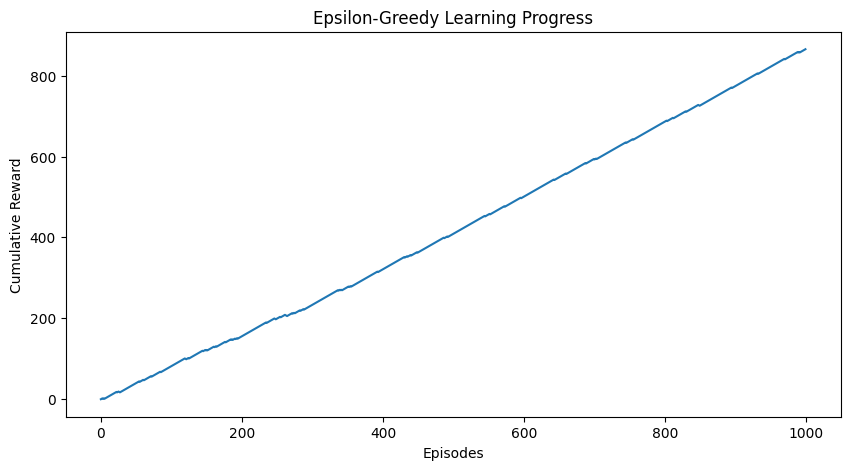

In [10]:
plt.figure(figsize=(10,5))

plt.plot(total_rewards)

plt.xlabel("Episodes")

plt.ylabel("Cumulative Reward")

plt.title("Epsilon-Greedy Learning Progress")

plt.show()

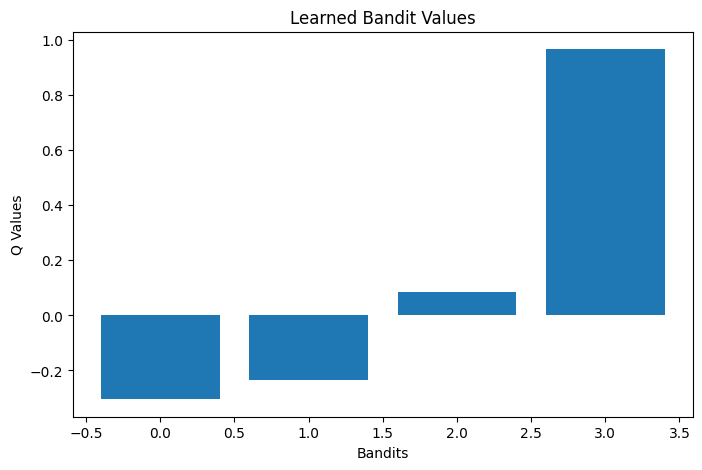

In [11]:
plt.figure(figsize=(8,5))

plt.bar(range(num_bandits), Q)

plt.xlabel("Bandits")

plt.ylabel("Q Values")

plt.title("Learned Bandit Values")

plt.show()